In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [2]:
df_final = pd.read_csv("cleaned_startup_data_new.csv")


In [3]:
df_final

,status,funding_rounds,funding_total_usd,milestones,relationships,has_geo,first_funding_at_missing,last_funding_at_missing,first_milestone_at_missing,last_milestone_at_missing,...,state_code_WA,state_code_other,isClosed,active_days,founded_year,age_days,days_to_first_funding,funding_duration_days,investment_duration_days,milestone_duration_days
0,1,0.0,0.0,0.0,2.0,1,1,1,1,1,...,0.0,0.0,1,18627,1970,20339,0.0,0.0,0,0.0
1,1,0.0,0.0,0.0,0.0,1,1,1,1,1,...,0.0,0.0,1,18627,1970,20339,0.0,0.0,0,0.0
2,1,0.0,0.0,1.0,2.0,1,1,1,0,0,...,0.0,1.0,1,18627,1970,20339,0.0,0.0,0,0.0
3,1,0.0,0.0,1.0,3.0,1,1,1,0,0,...,0.0,0.0,1,18627,1970,20339,0.0,0.0,0,0.0
4,1,0.0,0.0,1.0,2.0,1,1,1,0,0,...,0.0,0.0,1,18627,1970,20339,0.0,0.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47613,1,0.0,0.0,1.0,5.0,1,1,1,0,0,...,0.0,1.0,1,18627,1970,20339,0.0,0.0,0,0.0
47614,1,0.0,0.0,0.0,0.0,1,1,1,1,1,...,0.0,0.0,1,18627,1970,20339,0.0,0.0,0,0.0
47615,1,0.0,0.0,2.0,5.0,1,1,1,0,0,...,0.0,0.0,1,18627,1970,20339,0.0,0.0,0,0.0
47616,1,0.0,0.0,0.0,1.0,1,1,1,1,1,...,0.0,0.0,1,18627,1970,20339,0.0,0.0,0,0.0


In [4]:
# Define leakage features you found
leakage_features = ["status", "target", "active_days"]

# Drop them from X if present
X_clean = df_final.drop(columns=[col for col in leakage_features if col in df_final.columns], errors="ignore")

print(f"✅ Features after removing leakage: {X_clean.shape[1]} (from {df_final.shape[1]})")

✅ Features after removing leakage: 46 (from 48)


In [5]:
X = df_final.drop('isClosed',axis=1)
y = df_final['isClosed']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE:", Counter(y_train))

smote = SMOTE(sampling_strategy=0.8, random_state=42)  
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE :", Counter(y_train_sm))


Before SMOTE: Counter({1: 35750, 0: 2344})
After SMOTE : Counter({1: 35750, 0: 28600})


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_sm_scaled = scaler.fit_transform(X_train_sm)
x_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(x_train_sm_scaled, y_train_sm)

LogisticRegression(max_iter=2000, random_state=42)

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import *


y_pred = log_reg.predict(x_test_scaled)
y_proba = log_reg.predict_proba(x_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

Accuracy: 1.0
ROC AUC: 1.0

Confusion Matrix:
 [[ 586    0]
 [   0 8938]]

Classification Report:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000       586
           1      1.000     1.000     1.000      8938

    accuracy                          1.000      9524
   macro avg      1.000     1.000     1.000      9524
weighted avg      1.000     1.000     1.000      9524



In [10]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42)

rf.fit(X_train_sm, y_train_sm)


RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [11]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

Accuracy: 1.0
ROC AUC: 1.0

Confusion Matrix:
 [[ 586    0]
 [   0 8938]]

Classification Report:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000       586
           1      1.000     1.000     1.000      8938

    accuracy                          1.000      9524
   macro avg      1.000     1.000     1.000      9524
weighted avg      1.000     1.000     1.000      9524



In [12]:
from sklearn.metrics import accuracy_score

y_train_pred = rf.predict(X_train_sm)
train_acc = accuracy_score(y_train_sm, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 1.0


📊 Logistic Regression (Cross-Validation)
accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1: 1.0000
roc_auc: 1.0000

🌲 Random Forest (Cross-Validation)
accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1: 1.0000
roc_auc: 1.0000

Original features: 47
PCA features: 31

📊 Logistic Regression with PCA
accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1: 1.0000
roc_auc: 1.0000


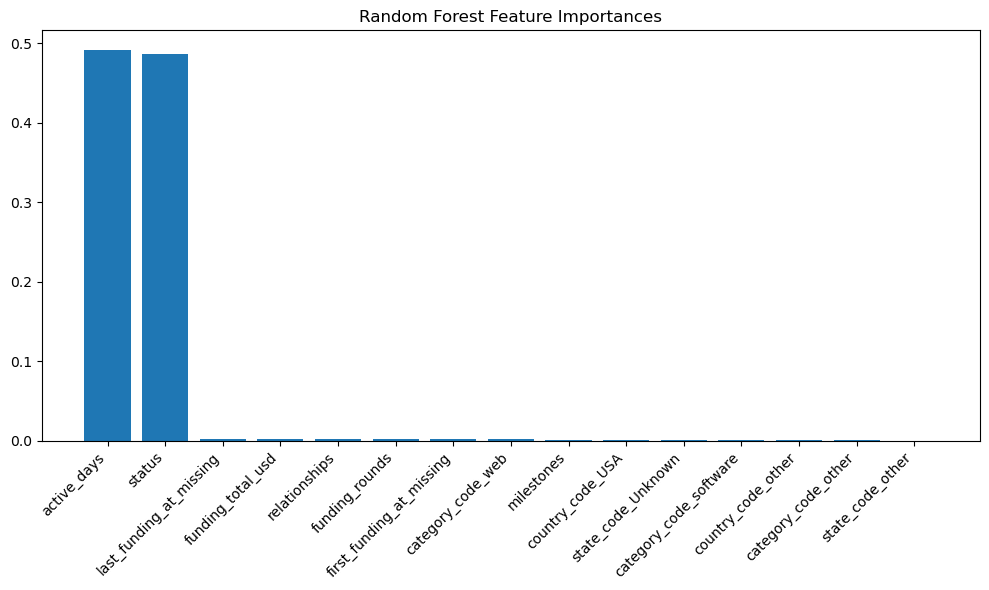

In [13]:
# =============================
# Phase 1: Strengthen Existing Models
# =============================

from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Define models
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf_clf = RandomForestClassifier(random_state=42)

# Define cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "f1": make_scorer(f1_score),
    "roc_auc": "roc_auc"
}

# =============================
# 1. Cross-validation Results
# =============================
print("📊 Logistic Regression (Cross-Validation)")
log_reg_cv = cross_validate(log_reg, X, y, cv=cv, scoring=scoring)
for metric in scoring.keys():
    print(f"{metric}: {log_reg_cv['test_' + metric].mean():.4f}")

print("\n🌲 Random Forest (Cross-Validation)")
rf_cv = cross_validate(rf_clf, X, y, cv=cv, scoring=scoring)
for metric in scoring.keys():
    print(f"{metric}: {rf_cv['test_' + metric].mean():.4f}")

# =============================
# 2. PCA-based Feature Comparison
# =============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA (keep 95% variance)
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\nOriginal features: {X.shape[1]}")
print(f"PCA features: {X_pca.shape[1]}")

# Evaluate Logistic Regression with PCA features
print("\n📊 Logistic Regression with PCA")
log_reg_cv_pca = cross_validate(log_reg, X_pca, y, cv=cv, scoring=scoring)
for metric in scoring.keys():
    print(f"{metric}: {log_reg_cv_pca['test_' + metric].mean():.4f}")

# =============================
# 3. Feature Importance (Random Forest)
# =============================
rf_clf.fit(X, y)
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Random Forest Feature Importances")
plt.bar(range(15), importances[indices[:15]], align="center")
plt.xticks(range(15), X.columns[indices[:15]], rotation=45, ha="right")
plt.tight_layout()
plt.show()



📊 Correlation of features with target (isClosed):
status                            1.000000
isClosed                          1.000000
active_days                       1.000000
first_funding_at_missing          0.108713
last_funding_at_missing           0.108713
state_code_Unknown                0.068585
country_code_IND                  0.048058
country_code_other                0.042956
category_code_consulting          0.036115
category_code_other               0.032357
days_to_first_funding             0.031912
category_code_ecommerce           0.020893
country_code_ESP                  0.016442
category_code_advertising         0.011666
country_code_NLD                  0.009394
country_code_CAN                  0.008456
state_code_FL                     0.006925
country_code_FRA                  0.005885
country_code_GBR                  0.005673
last_milestone_at_missing         0.003308
first_milestone_at_missing        0.003308
country_code_DEU                 -0.002370
sta

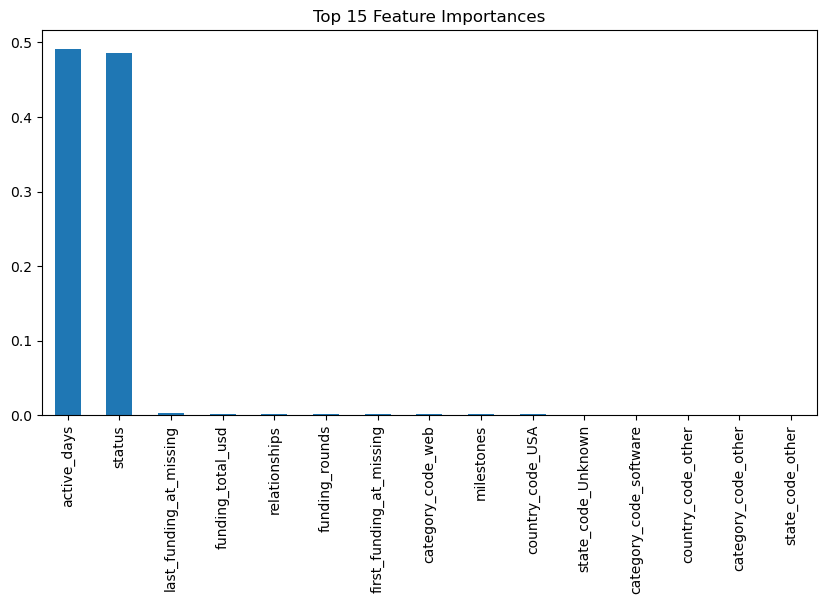

In [14]:
# =============================
# 🔍 Step: Check for Data Leakage (Fixed)
# =============================

# Make sure target exists in the dataframe
if "isClosed" not in df_final.columns:
    df_with_target = df_final.copy()
    df_with_target["isClosed"] = y   # add back target
else:
    df_with_target = df_final

# 1. Correlation with target
corr_with_target = df_with_target.corr()["isClosed"].sort_values(ascending=False)
print("\n📊 Correlation of features with target (isClosed):")
print(corr_with_target)

# Highlight potential leakage (features with |correlation| > 0.95)
leakage_features = corr_with_target[abs(corr_with_target) > 0.95].drop("isClosed", errors="ignore")
if not leakage_features.empty:
    print("\n⚠️ Possible leakage features detected:")
    print(leakage_features)

# 2. Random Forest Feature Importances
rf_clf.fit(X, y)
importances = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\n🌲 Top 10 Important Features (Random Forest):")
print(importances.head(10))

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
importances.head(15).plot(kind="bar")
plt.title("Top 15 Feature Importances")
plt.show()


✅ Features after removing leakage: 45 (from 47)

📊 Model Performance After Removing Leakage:


,accuracy,precision,recall,f1,roc_auc
Logistic Regression (No Leakage),0.938469,0.938469,1.000000,0.968258,0.555900
Random Forest (No Leakage),0.931349,0.940075,0.989953,0.964369,0.628473



🌲 Top 10 Important Features (Random Forest, No Leakage):
relationships              0.258012
funding_total_usd          0.246677
milestones                 0.035146
category_code_web          0.033282
funding_rounds             0.030532
category_code_software     0.024946
has_geo                    0.022302
state_code_other           0.019838
category_code_mobile       0.017879
category_code_ecommerce    0.017838
dtype: float64


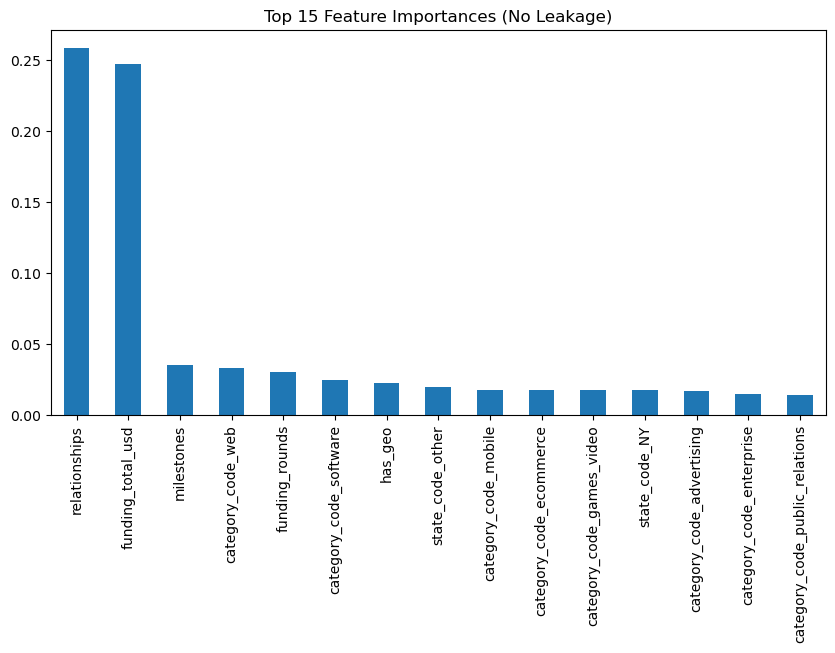

In [15]:
# =============================
# 🚫 Remove Leakage Features & Re-run Models
# =============================

# Define leakage features you found
leakage_features = ["status", "target", "active_days"]

# Drop them from X if present
X_clean = X.drop(columns=[col for col in leakage_features if col in X.columns], errors="ignore")

print(f"✅ Features after removing leakage: {X_clean.shape[1]} (from {X.shape[1]})")

# Re-run cross-validation
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf_clf = RandomForestClassifier(random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "f1": make_scorer(f1_score),
    "roc_auc": "roc_auc"
}

# Function to get results
def get_cv_results(model, X, y, cv, scoring):
    results = cross_validate(model, X, y, cv=cv, scoring=scoring)
    return {metric: results['test_' + metric].mean() for metric in scoring.keys()}

# Collect results
results_dict = {
    "Logistic Regression (No Leakage)": get_cv_results(log_reg, X_clean, y, cv, scoring),
    "Random Forest (No Leakage)": get_cv_results(rf_clf, X_clean, y, cv, scoring),
}

# Convert to DataFrame
results_df = pd.DataFrame(results_dict).T
print("\n📊 Model Performance After Removing Leakage:")
display(results_df)

# Feature Importance again (Random Forest)
rf_clf.fit(X_clean, y)
importances = pd.Series(rf_clf.feature_importances_, index=X_clean.columns).sort_values(ascending=False)

print("\n🌲 Top 10 Important Features (Random Forest, No Leakage):")
print(importances.head(10))

# Plot
plt.figure(figsize=(10,5))
importances.head(15).plot(kind="bar")
plt.title("Top 15 Feature Importances (No Leakage)")
plt.show()


In [16]:
# =============================
# 📊 Training vs Testing Accuracy
# =============================

# Train-test split on cleaned features
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression
log_reg.fit(X_train, y_train)
y_train_pred_lr = log_reg.predict(X_train)
y_test_pred_lr = log_reg.predict(X_test)

print("\n📈 Logistic Regression Performance")
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_lr):.4f}")
print(f"Testing Accuracy : {accuracy_score(y_test, y_test_pred_lr):.4f}")

# Random Forest
rf_clf.fit(X_train, y_train)
y_train_pred_rf = rf_clf.predict(X_train)
y_test_pred_rf = rf_clf.predict(X_test)

print("\n🌲 Random Forest Performance")
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_rf):.4f}")
print(f"Testing Accuracy : {accuracy_score(y_test, y_test_pred_rf):.4f}")



📈 Logistic Regression Performance
Training Accuracy: 0.9385
Testing Accuracy : 0.9385

🌲 Random Forest Performance
Training Accuracy: 0.9598
Testing Accuracy : 0.9300


In [17]:
pip install lightgbm


Note: you may need to restart the kernel to use updated packages.


In [19]:
# ==============================
# Phase 2: Advanced Models
# ==============================

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import cross_val_score

# Define models
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
lgbm = LGBMClassifier(random_state=42, verbose=-1)
gbc = GradientBoostingClassifier(random_state=42)

# Voting ensemble
voting = VotingClassifier(
    estimators=[("xgb", xgb), ("lgbm", lgbm), ("gbc", gbc)],
    voting="hard"
)

# Cross-validation
models = {"XGBoost": xgb, "LightGBM": lgbm, "GradientBoosting": gbc, "VotingClassifier": voting}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="f1")
    print(f"{name}: Mean F1 = {scores.mean():.4f} | Std = {scores.std():.4f}")


C:\Users\anike\anaconda3\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\anike\anaconda3\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\anike\anaconda3\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\anike\anaconda3\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\anike\anaconda3\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\anike\anaconda3\Lib\site-packages\xgboost\sklearn.p

XGBoost: Mean F1 = 1.0000 | Std = 0.0000
LightGBM: Mean F1 = 1.0000 | Std = 0.0000
GradientBoosting: Mean F1 = 1.0000 | Std = 0.0000


C:\Users\anike\anaconda3\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\anike\anaconda3\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\anike\anaconda3\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\anike\anaconda3\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\anike\anaconda3\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\anike\anaconda3\Lib\site-packages\xgboost\sklearn.p

VotingClassifier: Mean F1 = 1.0000 | Std = 0.0000


Class distribution:
1    0.938469
0    0.061531
Name: isClosed, dtype: float64
LogReg Balanced ROC-AUC (CV): 0.6213 ± 0.0820
RF Balanced ROC-AUC (CV): 0.5581 ± 0.0308

LogReg Calibrated Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       586
           1       0.94      1.00      0.97      8938

    accuracy                           0.94      9524
   macro avg       0.47      0.50      0.48      9524
weighted avg       0.88      0.94      0.91      9524

Confusion Matrix:
[[   0  586]
 [   0 8938]]


C:\Users\anike\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\anike\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\anike\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



RF Calibrated Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       586
           1       0.94      1.00      0.97      8938

    accuracy                           0.94      9524
   macro avg       0.47      0.50      0.48      9524
weighted avg       0.88      0.94      0.91      9524

Confusion Matrix:
[[   0  586]
 [   0 8938]]


C:\Users\anike\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\anike\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\anike\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


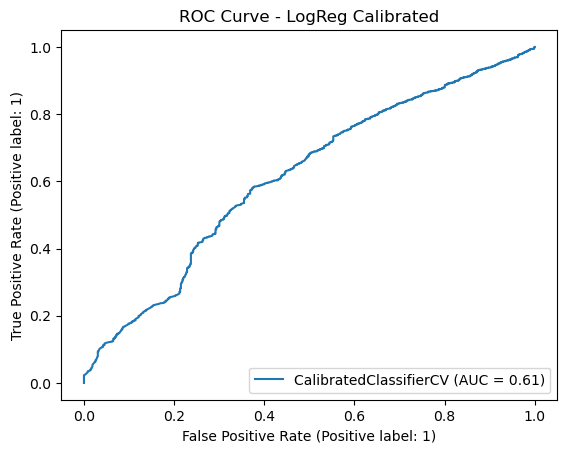

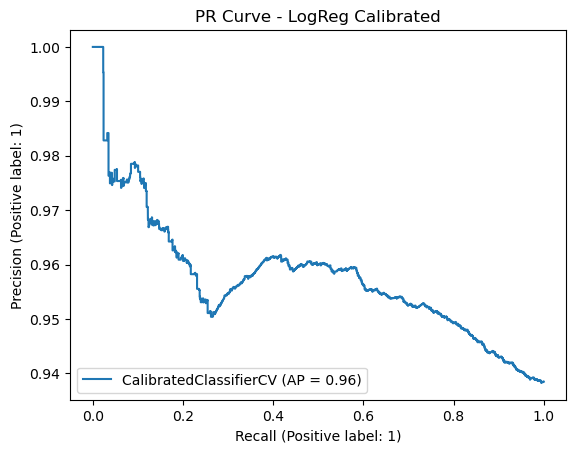

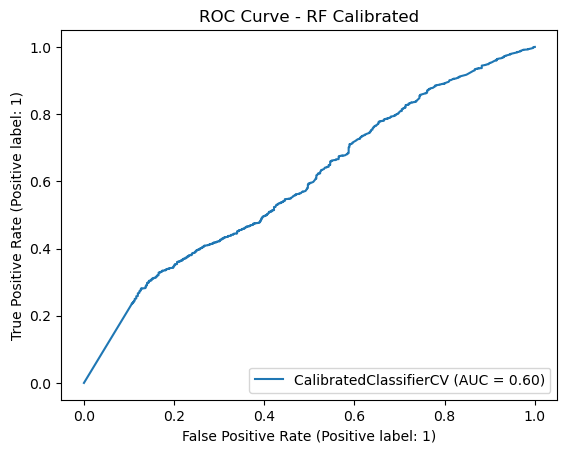

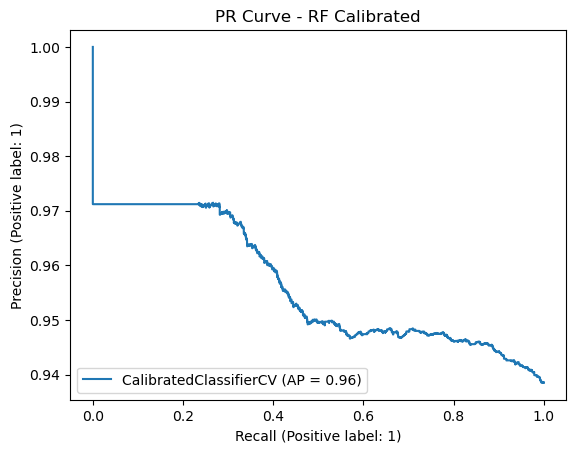

In [20]:
# ================================
# 📊 Phase 1.5 – Diagnostics & Fixes
# ================================

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)

# 1. ✅ Check class balance
print("Class distribution:")
print(y.value_counts(normalize=True))

# 2. ✅ Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, stratify=y, random_state=42
)

# 3. ✅ Define models with class_weight balanced
log_reg_bal = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
rf_bal = RandomForestClassifier(class_weight="balanced", random_state=42)

# 4. ✅ Apply probability calibration
calibrated_log_reg = CalibratedClassifierCV(log_reg_bal, cv=5)
calibrated_rf = CalibratedClassifierCV(rf_bal, cv=5)

# Fit models
calibrated_log_reg.fit(X_train, y_train)
calibrated_rf.fit(X_train, y_train)

# 5. ✅ Evaluate with ROC-AUC via cross-validation
for model, name in [(log_reg_bal, "LogReg Balanced"), (rf_bal, "RF Balanced")]:
    auc_scores = cross_val_score(model, X_clean, y, cv=5, scoring="roc_auc")
    print(f"{name} ROC-AUC (CV): {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")

# 6. ✅ Confusion Matrix & Classification Report
for model, name in [(calibrated_log_reg, "LogReg Calibrated"), (calibrated_rf, "RF Calibrated")]:
    y_pred = model.predict(X_test)
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# 7. ✅ Plot ROC & PR Curves
for model, name in [(calibrated_log_reg, "LogReg Calibrated"), (calibrated_rf, "RF Calibrated")]:
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"ROC Curve - {name}")
    plt.show()

    PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"PR Curve - {name}")
    plt.show()


Class distribution:
 1    0.938469
0    0.061531
Name: isClosed, dtype: float64

After SMOTE balancing:
 1    0.5
0    0.5
Name: isClosed, dtype: float64

 Logistic Regression 
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       586
           1       1.00      1.00      1.00      8938

    accuracy                           1.00      9524
   macro avg       1.00      1.00      1.00      9524
weighted avg       1.00      1.00      1.00      9524

Confusion Matrix:
 [[ 586    0]
 [   0 8938]]

 Random Forest 
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       586
           1       1.00      1.00      1.00      8938

    accuracy                           1.00      9524
   macro avg       1.00      1.00      1.00      9524
weighted avg       1.00      1.00      1.00      9524

Confusion Matrix:
 [[ 586    0]
 [   0 8938]]

Final Compa

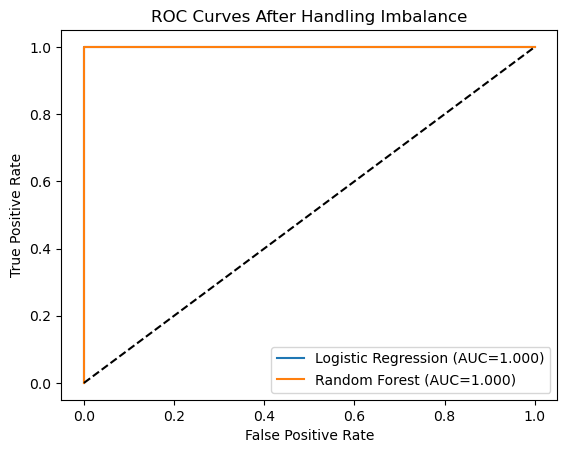

In [23]:
# =============================
# 📌 Handling Class Imbalance + Model Evaluation
# =============================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# =============================
# ✅ Load Data
# =============================
df = df_final.copy()   # use your preprocessed dataset
X = df.drop(columns=["isClosed"])
y = df["isClosed"]

print("Class distribution:\n", y.value_counts(normalize=True))

# =============================
# 🚀 Train-Test Split
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# =============================
# ⚖️ Balance with SMOTE
# =============================
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("\nAfter SMOTE balancing:\n", y_train_res.value_counts(normalize=True))

# =============================
# 🔹 Models with class_weight
# =============================
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=500, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42
    )
}

results = []

# =============================
# 🏃 Train, Predict, Evaluate
# =============================
for name, model in models.items():
    print(f"\n=============================")
    print(f" {name} ")
    print(f"=============================")

    # Fit on SMOTE-resampled training data
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = model.score(X_test, y_test)
    prec = classification_report(y_test, y_pred, output_dict=True)["1"]["precision"]
    rec = classification_report(y_test, y_pred, output_dict=True)["1"]["recall"]
    f1 = classification_report(y_test, y_pred, output_dict=True)["1"]["f1-score"]
    roc_auc = roc_auc_score(y_test, y_proba)

    results.append([name, acc, prec, rec, f1, roc_auc])

    # Reports
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

# =============================
# 📊 Results Table
# =============================
results_df = pd.DataFrame(
    results, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
)
print("\nFinal Comparison:\n", results_df)

# =============================
# 🎯 Plot ROC Curves
# =============================
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves After Handling Imbalance")
plt.legend()
plt.show()
